**Импорт библиотек**

In [2]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

**Загрузка данных и первичный анализ (EDA)**

На этом этапе исследуем структуру датасета и определяем: количество строк и столбцов, типы данных и наличие пропусков, базовые статистики числовых признаков, распределение целевой переменной survived.

In [4]:
df = sns.load_dataset("titanic")

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


**Предобработка данных**

Перед обучением модели необходимо удалить избыточные/дублирующие столбцы (embarked, class, alive) и проанализировать пропущенные значения. Также подготовить данные для модели.

In [5]:
df.drop(["embarked", "class", "alive"], axis = 1, inplace = True)

In [36]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,man,True,Southampton,False
1,1,1,female,38.0,1,0,71.2833,woman,False,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,woman,False,Southampton,True
3,1,1,female,35.0,1,0,53.1000,woman,False,Southampton,False
4,0,3,male,35.0,0,0,8.0500,man,True,Southampton,True


**Исследовательский анализ данных**

Проверим качество данных:

* общее количество пропусков по каждому признаку
* распределение целевой переменной
* влияние категориальных и числовых признаков на выживание

In [6]:
null_num = []
for i in df.columns:
    x = df[i].isnull().sum()
    null_num.append(x)

In [9]:
null_num

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(177),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(688),
 np.int64(2),
 np.int64(0)]

In [11]:
pd.DataFrame(null_num, index = df.columns, columns=["Total Missing Values"])

,Total Missing Values
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
who,0
adult_male,0
deck,688


<Axes: xlabel='deck', ylabel='count'>

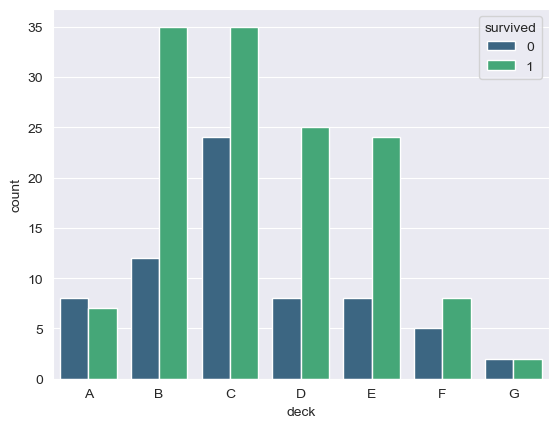

In [15]:
sns.set_style("darkgrid")
sns.countplot(x = "deck", hue = "survived", data = df, palette = "viridis")

In [7]:
df.drop(["deck"], axis = 1, inplace = True)

<Axes: xlabel='pclass', ylabel='age'>

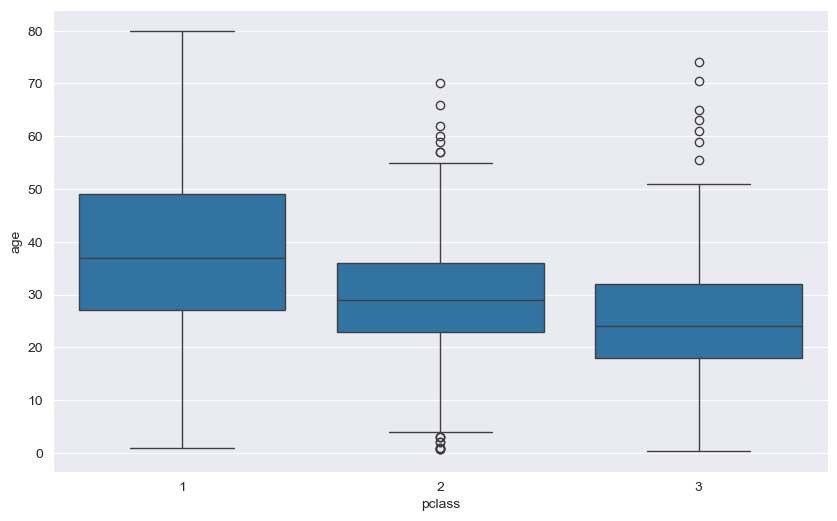

In [17]:
plt.figure(figsize = (10,6))
sns.boxplot(x = "pclass", y = "age", data = df)

In [8]:
def fillna_age(columns):
    age = columns[0]
    pclass = columns[1]

    if pd.isnull(age):
        if pclass == 1:
            return 38
        elif pclass == 2:
            return 29
        else:
            return 23
    else:   
        return age

In [9]:
df.age = df[["age", "pclass"]].apply(fillna_age, axis = 1)

In [14]:
null_num = []
for i in df.columns:
    x = df[i].isnull().sum()
    null_num.append(x)

pd.DataFrame(null_num, index = df.columns, columns=["Total Missing Values"])

,Total Missing Values
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
who,0
adult_male,0
embark_town,0


In [13]:
df.dropna(inplace = True)

<Axes: xlabel='survived', ylabel='count'>

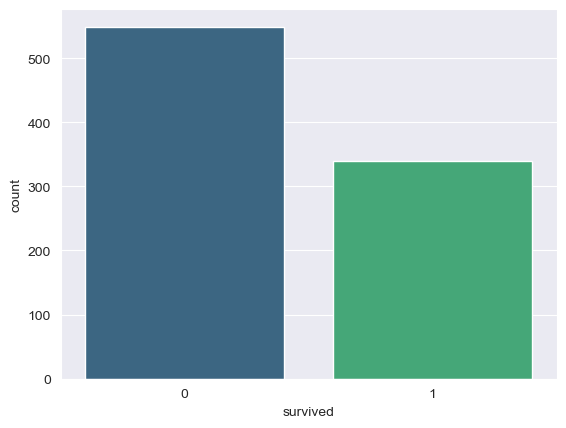

In [15]:
sns.set_style("darkgrid")
sns.countplot(x = "survived", data = df, palette = "viridis")

In [16]:
df.survived.value_counts()

survived
0    549
1    340
Name: count, dtype: int64

**Бинарный анализ**

<Axes: xlabel='survived', ylabel='count'>

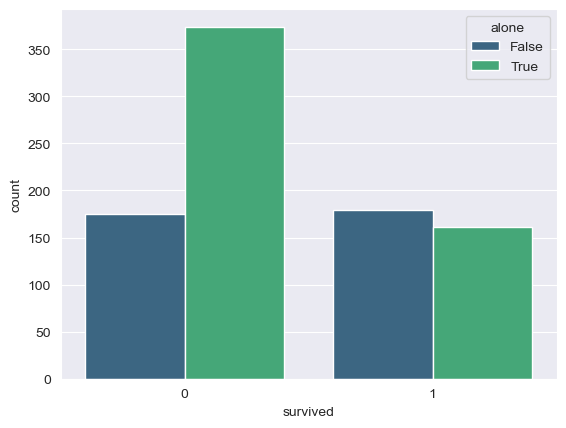

In [18]:
sns.set_style("darkgrid")
sns.countplot(x = "survived", hue = "alone", data = df, palette = "viridis")

<Axes: xlabel='survived', ylabel='count'>

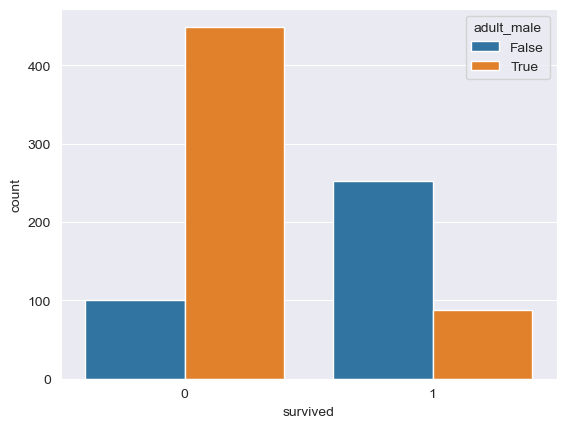

In [20]:
sns.set_style("darkgrid")
sns.countplot(x = "survived", hue = "adult_male", data = df)

<Axes: xlabel='survived', ylabel='count'>

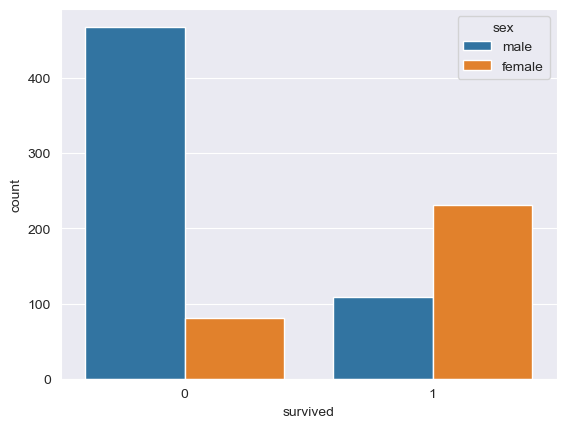

In [21]:
sns.set_style("darkgrid")
sns.countplot(x = "survived", hue = "sex", data = df)

<Axes: xlabel='survived', ylabel='count'>

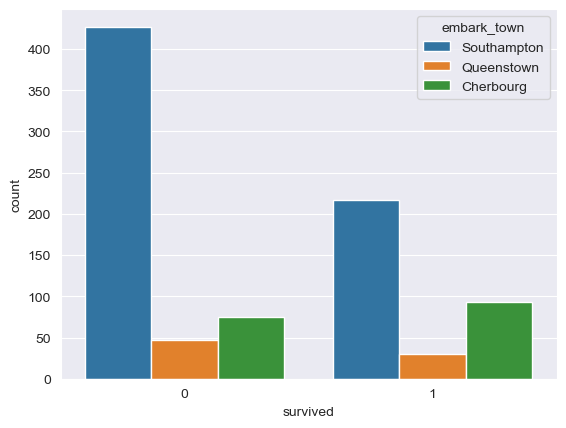

In [22]:
sns.set_style("darkgrid")
sns.countplot(x = "survived", hue = "embark_town", data = df)

In [23]:
df.embark_town.value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='Density'>

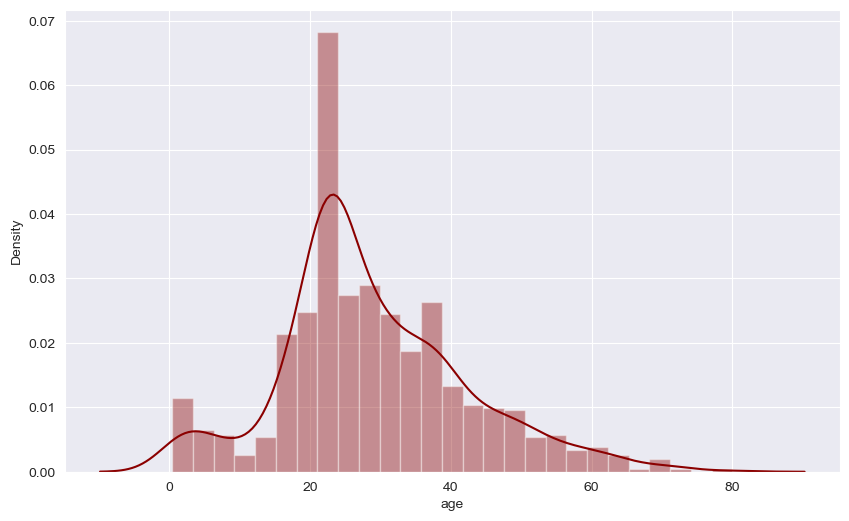

In [25]:
plt.figure(figsize = (10,6))
sns.distplot(df["age"], color ="darkred")

<Axes: xlabel='fare', ylabel='Density'>

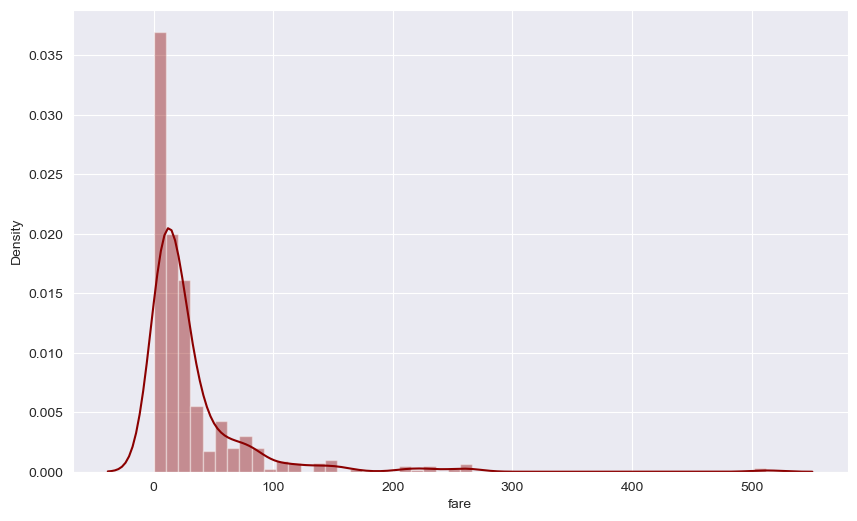

In [26]:
plt.figure(figsize = (10,6))
sns.distplot(df["fare"], color ="darkred")

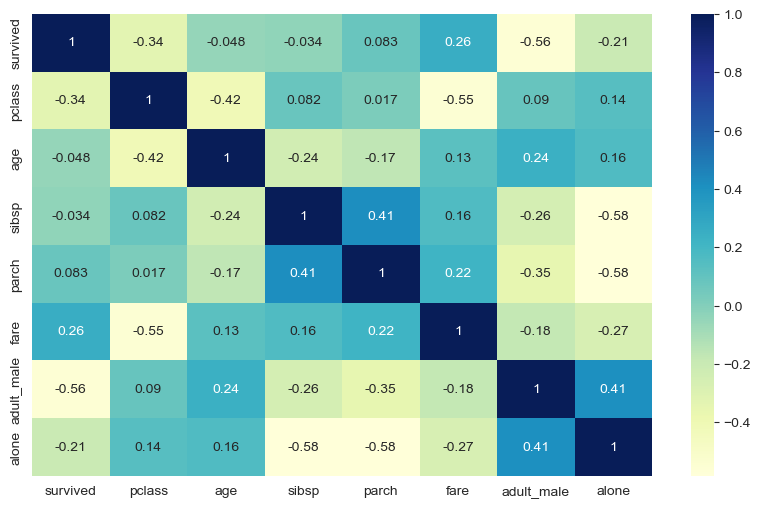

In [39]:
plt.figure(figsize = (10, 6)) 
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)  
plt.show() 

**Подготовка данных для модели**

Кодируем категориальные переменные (sex, who, embark_town, adult_male, alone) и обрабатываем пропуски в age и deck (медиана / мода / удаление).
Разделяем данные на train/test

In [40]:
df.drop(["age","sibsp","parch"], axis = 1, inplace = True)

In [41]:
df.head()

,survived,pclass,sex,fare,who,adult_male,embark_town,alone
0,0,3,male,7.2500,man,True,Southampton,False
1,1,1,female,71.2833,woman,False,Cherbourg,False
2,1,3,female,7.9250,woman,False,Southampton,True
3,1,1,female,53.1000,woman,False,Southampton,False
4,0,3,male,8.0500,man,True,Southampton,True


In [46]:
sex = pd.get_dummies(df["sex"], drop_first = True)
who = pd.get_dummies(df["who"], drop_first = True)
adult_male = pd.get_dummies(df["adult_male"], drop_first = True)
embark_town = pd.get_dummies(df["embark_town"], drop_first = True)
alone = pd.get_dummies(df["alone"], drop_first = True)

In [47]:
df = pd.concat([df, sex, who, adult_male, embark_town, alone], axis = 1)

In [48]:
df.head()

,survived,pclass,sex,fare,who,adult_male,embark_town,alone,male,man,woman,True,Queenstown,Southampton,True
0,0,3,male,7.2500,man,True,Southampton,False,True,True,False,True,False,True,False
1,1,1,female,71.2833,woman,False,Cherbourg,False,False,False,True,False,False,False,False
2,1,3,female,7.9250,woman,False,Southampton,True,False,False,True,False,False,True,True
3,1,1,female,53.1000,woman,False,Southampton,False,False,False,True,False,False,True,False
4,0,3,male,8.0500,man,True,Southampton,True,True,True,False,True,False,True,True


In [49]:
df.drop(["sex","who","adult_male","embark_town","alone"], axis = 1, inplace = True)

In [50]:
df.head()

,survived,pclass,fare,male,man,woman,True,Queenstown,Southampton,True
0,0,3,7.2500,True,True,False,True,False,True,False
1,1,1,71.2833,False,False,True,False,False,False,False
2,1,3,7.9250,False,False,True,False,False,True,True
3,1,1,53.1000,False,False,True,False,False,True,False
4,0,3,8.0500,True,True,False,True,False,True,True


**Обучение модели Logistic Regression**

Используем логистическую регрессию как базовую модель бинарной классификации.
Модель обучается на подготовленных признаках для предсказания выживания пассажиров

In [51]:
from sklearn.model_selection import train_test_split

In [62]:
X = df.drop("survived", axis = 1)
y = df["survived"]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [57]:
from sklearn.linear_model import LogisticRegression

In [58]:
lr_model = LogisticRegression()

In [68]:
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

lr_model.fit(X_train, y_train)

LogisticRegression()

In [69]:
y_pred = lr_model.predict(X_test)

In [70]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [71]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83       141
           1       0.68      0.79      0.73        82

    accuracy                           0.79       223
   macro avg       0.78      0.79      0.78       223
weighted avg       0.80      0.79      0.79       223



In [72]:
cnf_matrix = confusion_matrix(y_test, y_pred)

In [73]:
cnf_matrix

array([[111,  30],
       [ 17,  65]])

**Выводы и рекомендации**

Модель логистической регрессии показала accuracy 0.79 на тестовой выборке. Это хороший результат для базовой модели без сложного feature engineering.
Ключевые инсайты:

Пол (sex) и класс билета (pclass) оказались самыми значимыми предикторами выживания — женщины и пассажиры 1-го класса имели значительно более высокие шансы выжить.
Возраст и наличие родственников (sibsp, parch) также влияют, но в меньшей степени.
Модель хорошо распознаёт оба класса (выжившие / погибшие), однако recall по классу «выжил» (0.79) можно ещё улучшить.

Что можно улучшить в следующих итерациях:

Добавить feature engineering (создать признак «семья», возрастные группы, title из имени)
Протестировать другие модели (Random Forest, XGBoost, CatBoost)
Применить кросс-валидацию и подбор гиперпараметров (GridSearchCV / Optuna)
Построить ROC-AUC и PR-кривую для более полной оценки

Общий вывод:
Проект демонстрирует полный цикл работы Data Scientist/ML-инженера — от EDA до обучения и оценки модели. Полученная точность 79% подтверждает, что даже простая логистическая регрессия на хорошо подготовленных данных даёт сильный baseline для задачи предсказания выживания на «Титанике».